# Step 1: Install the environment

In [1]:
!nvidia-smi
!pip install --upgrade protobuf==5.29.1
!pip install numpy==1.26.0
!pip install wandb==0.16.3
!pip install --upgrade accelerate diffusers[training]
!pip install -q transformers datasets peft bitsandbytes xformers huggingface_hub

Sat Apr 18 05:23:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 75.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
music21 9.9.1 requires numpy>=1.26.4, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have n

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 28.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.1
    Uninstalling protobuf-5.29.1:
      Successfully uninstalled protobuf-5.29.1
  Attempting uninstall: wandb
    Found existing installation: wandb 0.25.1
    Uninstalling wandb-0.25.1:
      Successfully uninstalled wandb-0.25.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-monitoring 2.30.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-bigquery-connection 1.21.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-translate 3.26.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
googleapis-common-protos 1.74.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
google-cloud-

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 111.8 MB/s eta 0:00:00


# Step 2: Upload and check the training data

In [1]:
import os
image_dir = "/content/sticker_images"
os.makedirs(image_dir, exist_ok=True)

In [2]:
images = os.listdir(image_dir)
print(f"find {len(images)} picturs：{images[:]}")
if len(images) == 0:
    raise Exception("upload /content/sticker_images first！")

find 5 picturs：['watercolor-hedgehog.jpg', 'watercolor-rabbit.jpg', 'watercolor-tiger.png', 'watercolor-goat.png', 'watercolor-wolf.jpg']


# Step 3: Diffusers

In [3]:
import os
os.environ["WANDB_DISABLED"] = "true"
!git clone https://github.com/huggingface/diffusers.git
%cd /content/diffusers

Cloning into 'diffusers'...
remote: Enumerating objects: 120319, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 120319 (delta 71), reused 33 (delta 33), pack-reused 120213 (from 3)
Receiving objects: 100% (120319/120319), 93.53 MiB | 26.87 MiB/s, done.
Resolving deltas: 100% (89627/89627), done.
/content/diffusers


# Step 4: Training Lora

In [4]:
%cd /content/diffusers
!pip install -e ".[torch]"
import diffusers

/content/diffusers
Obtaining file:///content/diffusers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 12.8 MB/s eta 0:00:00
  Building editable for diffusers (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-0.editable-py3-none-any.whl size=11406 sha256=055909a162a0a9b6068fb5a69e9a59eac4ed67b3f7cadb501fb003befc89e589
  Stored in directory: /tmp/pip-ephem-wheel-cache-xl44wn83/wheels/8a/fc/09/385efb77b455b2fd4a656c950079c93147e1f50ae614e51beb
Successfully built diffusers
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstal

In [5]:
# clean the history
!rm -rf /content/lora_sticker_model

# confirm the parameters
!python examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/sticker_images" \
  --output_dir="/content/lora_sticker_model" \
  --instance_prompt="a sks sticker style" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=1200 \
  --checkpointing_steps=200 \
  --mixed_precision="fp16" \
  --use_8bit_adam

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
tokenizer_config.json: 100% 806/806 [00:00<00:00, 3.54MB/s]
vocab.json: 1.06MB [00:00, 42.0MB/s]
merges.txt: 525kB [00:00, 115MB/s]
special_tokens_map.json: 100% 472/472 [00:00<00:00, 3.13MB/s]
config.json: 100% 617/617 [00:00<00:00, 3.28MB/s]
You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
scheduler_config.json: 100% 308/308 [00:

In [6]:
pip install bitsandbytes

In [7]:
import os
model_dir = "/content/lora_sticker_model"
print("exist?", os.path.exists(model_dir))

exist? True


# Step 5: Testing

In [8]:
!pip uninstall -y diffusers
!pip install diffusers[torch] --upgrade

Found existing installation: diffusers 0.38.0.dev0
Uninstalling diffusers-0.38.0.dev0:
  Successfully uninstalled diffusers-0.38.0.dev0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 74.0 MB/s eta 0:00:00


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

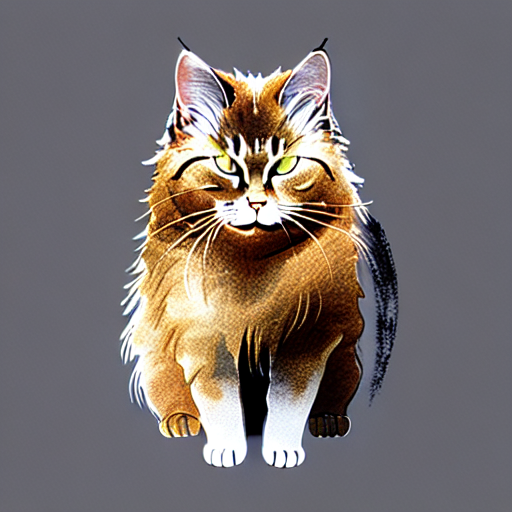

In [2]:
from diffusers import StableDiffusionPipeline
import torch
# loading models
pipe=StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")
pipe.unet.load_attn_procs("/content/lora_sticker_model")
# pipe.unet.load_attn_procs("/content/lora_sticker_model/checkpoint-400")
# generating pictures
animal = "cat"
prompt = f"a sks {animal} sticker style"
image = pipe(prompt, num_inference_steps=50).images[0]
image

# Step 6: Save the model to the Hugging face

In [3]:
import os
model_dir = "/content/lora_sticker_model"
print("exsit？", os.path.exists(model_dir))
if os.path.exists(model_dir):
    print("list：", os.listdir(model_dir))

exsit？ True
list： ['checkpoint-400', 'checkpoint-600', 'checkpoint-1200', 'checkpoint-800', 'checkpoint-200', 'pytorch_lora_weights.safetensors', 'checkpoint-1000', 'logs']


In [4]:
!find /content -name "*.json" 2>/dev/null
!find /content -name "*.safetensors" 2>/dev/null

/content/.config/.last_update_check.json
/content/sample_data/anscombe.json
/content/lora_sticker_model/checkpoint-400/pytorch_lora_weights.safetensors
/content/lora_sticker_model/checkpoint-600/pytorch_lora_weights.safetensors
/content/lora_sticker_model/checkpoint-1200/pytorch_lora_weights.safetensors
/content/lora_sticker_model/checkpoint-800/pytorch_lora_weights.safetensors
/content/lora_sticker_model/checkpoint-200/pytorch_lora_weights.safetensors
/content/lora_sticker_model/pytorch_lora_weights.safetensors
/content/lora_sticker_model/checkpoint-1000/pytorch_lora_weights.safetensors


In [5]:
import json
import os

model_dir = "/content/lora_sticker_model"
config = {
    "base_model_name_or_path": "runwayml/stable-diffusion-v1-5",
    "revision": None,
    "rank": 8,
    "alpha": 16,
    "dropout": 0.1,
    "target_modules": ["to_q", "to_k", "to_v", "to_out.0"]
}
with open(os.path.join(model_dir, "adapter_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("adapter_config.json existed", model_dir)

adapter_config.json existed /content/lora_sticker_model


In [10]:
from google.colab import files

files.download(os.path.join(model_dir, "pytorch_lora_weights.safetensors"))
files.download(os.path.join(model_dir, "adapter_config.json"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import zipfile
import os
folder_path = "/content/lora_sticker_model"
zip_filename = "lora_sticker_model.zip"
with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, folder_path)
            zipf.write(file_path, arcname)

from google.colab import files
files.download(zip_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


pytorch_lora_weights.safetensors:   0%|          | 0.00/3.23M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/diffusers/loaders/unet.py:214: FutureWarning: `load_attn_procs` is deprecated and will be removed in version 0.40.0. Using the `load_attn_procs()` method has been deprecated and will be removed in a future version. Please use `load_lora_adapter()`.
  deprecate("load_attn_procs", "0.40.0", deprecation_message)


  0%|          | 0/50 [00:00<?, ?it/s]

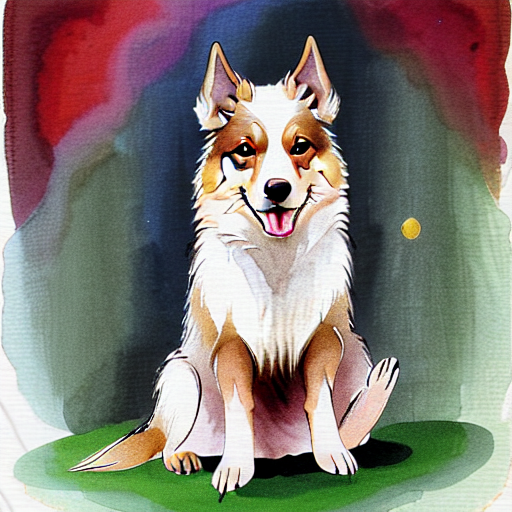

In [19]:
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to("cuda")
pipe.unet.load_attn_procs("Lilian0703/sticker-lora-watercolor")
image = pipe("a cute dog, a sks style").images[0]
image